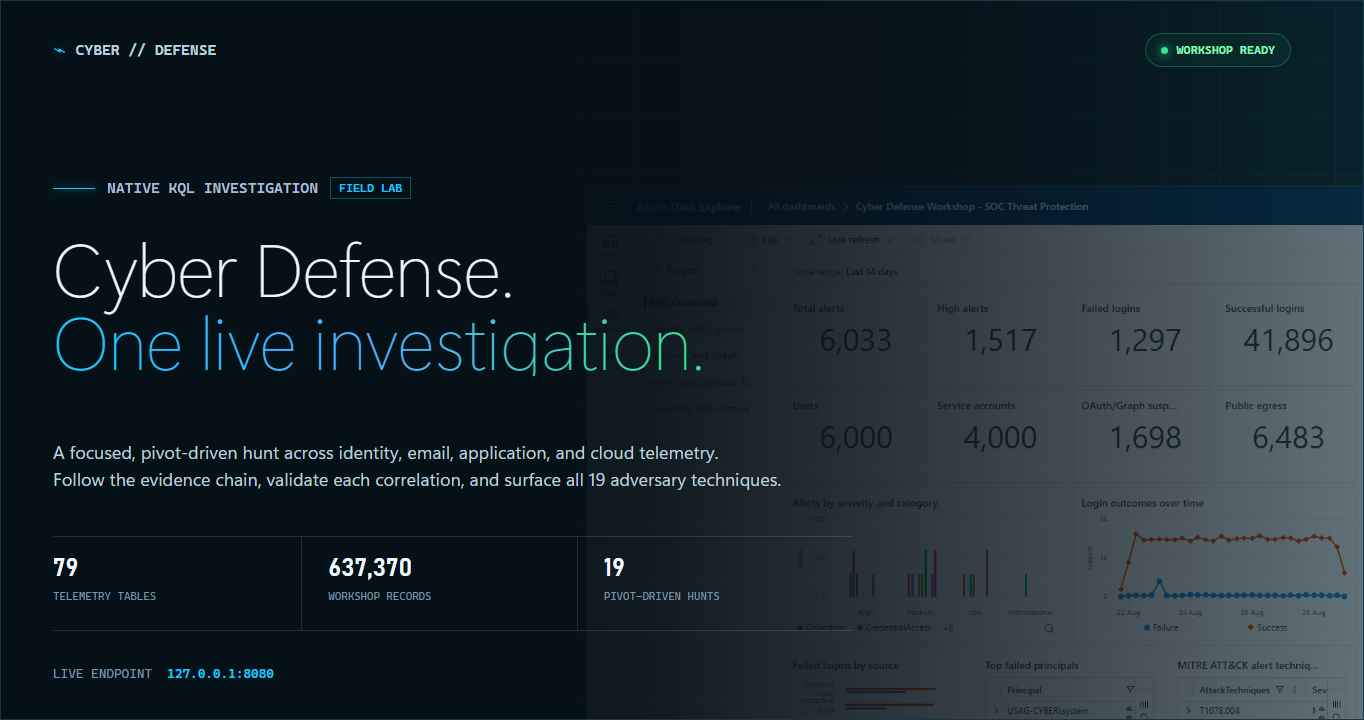

> **Live endpoint:** <code style="color:#58a6ff;font-weight:600">http://127.0.0.1:8080</code>  

**This notebook connects only to the existing workshop endpoint. It does not install or run Cloudflared, handle credentials, or manage containers.**

## 1 · Bootstrap the notebook environment

Run the next code cell before starting the Cloudflare proxy or connecting to ADX. It detects the operating system and CPU architecture, then checks for an existing `.venv` in the notebook working directory. A valid existing environment is reused without recreation. The cell checks that `IPython` and `ipykernel` are importable inside that environment and runs pip only for modules that are missing. It creates `.venv` only when the directory does not exist and registers the workshop kernel only when its current kernelspec is missing or points elsewhere.

A notebook cannot execute code until *some* Python kernel has started. For this one bootstrap run, select any available Python 3.10+ kernel. After the cell finishes, switch to **Python (.venv) - Cyber Defense Workshop** as instructed in its output. Rerunning the bootstrap cell is safe and performs checks only when the environment is already ready.

In [ ]:
import json
import platform
from pathlib import Path
import shlex
import subprocess
import sys

VENV_DIR = Path.cwd() / ".venv"
KERNEL_NAME = "cyber-defense-workshop"
KERNEL_DISPLAY_NAME = "Python (.venv) - Cyber Defense Workshop"
MINIMUM_PYTHON = (3, 10)
REQUIRED_MODULES = {
    "IPython": "ipython",
    "ipykernel": "ipykernel",
}


def normalize_architecture(machine):
    normalized = machine.strip().lower().replace("-", "_")
    if normalized in {"arm64", "aarch64"}:
        return "ARM64"
    if normalized in {"x86_64", "amd64"}:
        return "x86_64"
    if normalized in {"x86", "i386", "i686"}:
        return "x86"
    return machine or "unknown"


def select_platform_branch(system_name, machine):
    architecture = normalize_architecture(machine)

    if system_name == "Windows":
        if architecture == "ARM64":
            platform_label = "Windows on ARM64"
        elif architecture == "x86_64":
            platform_label = "Windows on x86_64"
        else:
            platform_label = f"Windows on {architecture}"
        return {
            "label": platform_label,
            "architecture": architecture,
            "venv_python": VENV_DIR / "Scripts" / "python.exe",
            "activation_command": r".\.venv\Scripts\Activate.ps1",
            "manual_create_command": "py -3 -m venv .venv",
            "repair_guidance": "Install Python 3.10 or newer from python.org, then reopen VS Code.",
        }

    if system_name == "Darwin":
        if architecture == "ARM64":
            platform_label = "macOS on Apple Silicon (ARM64)"
        elif architecture == "x86_64":
            platform_label = "macOS on Intel (x86_64)"
        else:
            platform_label = f"macOS on {architecture}"
        return {
            "label": platform_label,
            "architecture": architecture,
            "venv_python": VENV_DIR / "bin" / "python",
            "activation_command": "source .venv/bin/activate",
            "manual_create_command": "python3 -m venv .venv",
            "repair_guidance": "Install a native Python 3.10 or newer from python.org, then reopen VS Code.",
        }

    if system_name == "Linux":
        platform_label = f"Linux on {architecture}"
        return {
            "label": platform_label,
            "architecture": architecture,
            "venv_python": VENV_DIR / "bin" / "python",
            "activation_command": "source .venv/bin/activate",
            "manual_create_command": "python3 -m venv .venv",
            "repair_guidance": "Install Python 3.10+ plus your distribution's python3-venv and python3-pip packages.",
        }

    raise RuntimeError(
        f"Unsupported operating system: {system_name or 'unknown'} ({architecture}). "
        "Ask the instructor for a Python 3.10+ environment for this platform."
    )


def format_command(command, system_name):
    if system_name == "Windows":
        return subprocess.list2cmdline(command)
    return shlex.join(command)


def run_setup_step(description, command, system_name):
    print(f"\n{description}")
    print(f"> {format_command(command, system_name)}")
    subprocess.run(command, check=True)


def inspect_environment(python_executable, module_names):
    probe = (
        "import importlib.util, json, sys; "
        "modules = sys.argv[1:]; "
        "print(json.dumps({'version': list(sys.version_info[:3]), "
        "'missing': [name for name in modules if importlib.util.find_spec(name) is None]}))"
    )
    result = subprocess.run(
        [str(python_executable), "-c", probe, *module_names],
        check=True,
        capture_output=True,
        text=True,
    )
    try:
        inspection = json.loads(result.stdout.strip())
    except json.JSONDecodeError as error:
        raise RuntimeError(
            f"Could not inspect required modules in {python_executable}: {result.stdout!r}"
        ) from error
    return tuple(inspection["version"]), list(inspection["missing"])


def registered_kernel_interpreter(python_executable, kernel_name):
    probe = (
        "import json, sys; "
        "from jupyter_client.kernelspec import KernelSpecManager; "
        "spec = KernelSpecManager().get_all_specs().get(sys.argv[1], {}).get('spec', {}); "
        "argv = spec.get('argv', []); "
        "print(json.dumps(argv[0] if argv else None))"
    )
    result = subprocess.run(
        [str(python_executable), "-c", probe, kernel_name],
        check=True,
        capture_output=True,
        text=True,
    )
    registered_interpreter = json.loads(result.stdout.strip())
    if not registered_interpreter:
        return None
    return Path(registered_interpreter).resolve()


HOST_SYSTEM = platform.system()
HOST_MACHINE = platform.machine()
PLATFORM_BRANCH = select_platform_branch(HOST_SYSTEM, HOST_MACHINE)
venv_python = PLATFORM_BRANCH["venv_python"]

print(f"Detected platform: {PLATFORM_BRANCH['label']}")
print(f"Current Python: {platform.python_version()} ({sys.executable})")
print(f"Environment path: {VENV_DIR}")

if sys.version_info < MINIMUM_PYTHON:
    required_version = ".".join(str(part) for part in MINIMUM_PYTHON)
    raise RuntimeError(
        f"Python {required_version} or newer is required; this kernel uses {platform.python_version()}.\n"
        f"{PLATFORM_BRANCH['repair_guidance']}\n"
        f"Then create the environment with: {PLATFORM_BRANCH['manual_create_command']}"
    )

try:
    if VENV_DIR.exists():
        if not VENV_DIR.is_dir():
            raise RuntimeError(f"The expected .venv path is not a directory: {VENV_DIR}")
        if not venv_python.is_file():
            raise RuntimeError(
                f"The existing .venv has no interpreter at {venv_python}. "
                "Repair or remove that incomplete environment, then rerun this cell."
            )
        print("Found an existing workshop .venv; environment creation skipped.")
    else:
        run_setup_step(
            "No .venv found; creating the architecture-compatible environment...",
            [sys.executable, "-m", "venv", str(VENV_DIR)],
            HOST_SYSTEM,
        )
        if not venv_python.is_file():
            raise RuntimeError(f"The expected environment interpreter was not created: {venv_python}")

    target_version, missing_modules = inspect_environment(venv_python, list(REQUIRED_MODULES))
    if target_version[:2] < MINIMUM_PYTHON:
        required_version = ".".join(str(part) for part in MINIMUM_PYTHON)
        installed_version = ".".join(str(part) for part in target_version)
        raise RuntimeError(
            f"The existing .venv uses Python {installed_version}; Python {required_version} or newer is required. "
            "Repair or replace that environment, then rerun this cell."
        )

    if missing_modules:
        missing_packages = list(dict.fromkeys(REQUIRED_MODULES[name] for name in missing_modules))
        run_setup_step(
            f"Installing missing notebook modules: {', '.join(missing_modules)}...",
            [str(venv_python), "-m", "pip", "install", *missing_packages],
            HOST_SYSTEM,
        )
        _, remaining_modules = inspect_environment(venv_python, list(REQUIRED_MODULES))
        if remaining_modules:
            raise RuntimeError(
                f"Required modules are still unavailable after installation: {', '.join(remaining_modules)}"
            )
    else:
        print("Required modules already exist in .venv; pip installation skipped.")

    registered_interpreter = registered_kernel_interpreter(venv_python, KERNEL_NAME)
    if registered_interpreter == venv_python.resolve():
        print("The workshop kernel is already registered for this .venv; registration skipped.")
    else:
        run_setup_step(
            "Registering the workshop kernel for this .venv...",
            [
                str(venv_python),
                "-m",
                "ipykernel",
                "install",
                "--user",
                "--name",
                KERNEL_NAME,
                "--display-name",
                KERNEL_DISPLAY_NAME,
            ],
            HOST_SYSTEM,
        )
except (OSError, subprocess.CalledProcessError, RuntimeError) as error:
    raise RuntimeError(
        f"Environment setup failed for {PLATFORM_BRANCH['label']}: {error}\n\n"
        f"Platform guidance: {PLATFORM_BRANCH['repair_guidance']}\n"
        f"Manual retry: {PLATFORM_BRANCH['manual_create_command']}\n"
        "After correcting the issue, rerun this cell."
    ) from error

running_in_target_venv = Path(sys.prefix).resolve() == VENV_DIR.resolve()
print("\n\033[1;32mENVIRONMENT READY\033[0m")
print(f"Detected branch: {PLATFORM_BRANCH['label']}")
print(f"Environment interpreter: {venv_python}")
print("Verified modules: " + ", ".join(REQUIRED_MODULES))
print("Next steps:")
if running_in_target_venv:
    print(f"1. The notebook is already using {KERNEL_DISPLAY_NAME}.")
else:
    print(f"1. In VS Code, choose Select Kernel > {KERNEL_DISPLAY_NAME}.")
print("2. Restart the kernel if VS Code prompts you.")
print("3. Continue to Section 2 and start the workshop endpoint.")
print(f"Optional terminal activation: {PLATFORM_BRANCH['activation_command']}")

## 2 · Start the workshop endpoint

Before running the connection check, `http://127.0.0.1:8080` must already lead to one of these environments:

### Case 1 · Container is not local

Use the two files supplied by your instructor: `Start-StudentAdxProxy.ps1` and `student-access.env`. Open PowerShell in the folder that contains both files and start the student proxy:

```powershell
.\Start-StudentAdxProxy.ps1 -CredentialFile .\student-access.env
```

On macOS or Linux with PowerShell 7, use:

```bash
pwsh ./Start-StudentAdxProxy.ps1 -CredentialFile ./student-access.env
```

Keep that terminal open for the entire lab. The proxy listens on `127.0.0.1:8080` and forwards requests through Cloudflare Access and the read-only gateway to the remote Kustainer container.

```text
Notebook KQL request
    -> existing local proxy
    -> Cloudflare Access + Tunnel
    -> read-only Kusto gateway
    -> remote Kustainer
```

### Case 2 · Container is local

The already-running local Kustainer container publishes `127.0.0.1:8080`, so the notebook connects to it directly.

```text
Notebook KQL request
    -> 127.0.0.1:8080
    -> local Kustainer
```

The notebook does not create either route. It only decides whether the Kustainer container is local and then runs KQL through the endpoint already present.

## 3 · Verify the endpoint and create the KQL client

The connection code cell starts no process and always uses `http://127.0.0.1:8080`. A safe `.show cluster` status probe sets `CONTAINER_IS_LOCAL`:

- **`True`** when the local Kustainer endpoint returns HTTP 200.
- **`False`** when the existing read-only gateway returns HTTP 403.

The cell then requires Kusto ping and `CyberDefendStudentSnapshot` visibility. If the container is not local, it also verifies the existing gateway's `/healthz` endpoint. It never creates or changes a tunnel.

If the endpoint cannot be reached or is not ready, the returned error includes the exact student-proxy command and tells you to leave the proxy running before retrying. A successful check displays a green **CONNECTED** status with the route, endpoint, health checks, and database name.

In [ ]:
from __future__ import annotations

from html import escape
import json
import socket
import urllib.error
import urllib.parse
import urllib.request
from typing import Any

from IPython.core.getipython import get_ipython
from IPython.display import HTML, display

KUSTO_BASE_URL = "http://127.0.0.1:8080"
KUSTO_DATABASE = "CyberDefendStudentSnapshot"
WINDOWS_PROXY_COMMAND = r".\Start-StudentAdxProxy.ps1 -CredentialFile .\student-access.env"
POSIX_PROXY_COMMAND = "pwsh ./Start-StudentAdxProxy.ps1 -CredentialFile ./student-access.env"
COLOR_GREEN = "#3fb950"
COLOR_PURPLE = "#bc8cff"
COLOR_AMBER = "#f0a45d"
COLOR_CODE_BACKGROUND = "#202124"


def cloudflare_connection_help() -> str:
    return (
        "How to connect through Cloudflare:\n"
        "1. Put Start-StudentAdxProxy.ps1 and student-access.env in the same folder.\n"
        "2. Open PowerShell in that folder and run the command for your system:\n"
        f"   Windows: {WINDOWS_PROXY_COMMAND}\n"
        f"   macOS/Linux: {POSIX_PROXY_COMMAND}\n"
        "3. Leave the proxy terminal open, then rerun this cell.\n"
        "If your instructor assigned the local-container route, start Kustainer instead "
        "so it publishes 127.0.0.1:8080."
    )


def local_endpoint_is_listening(base_url: str) -> bool:
    parsed = urllib.parse.urlparse(base_url)
    if parsed.scheme != "http" or not parsed.hostname or not parsed.port:
        raise ValueError("KUSTO_BASE_URL must be an HTTP URL with an explicit local port.")
    if parsed.hostname not in {"127.0.0.1", "localhost", "::1"}:
        raise ValueError("KUSTO_BASE_URL must point to a loopback address, not the public hostname.")
    try:
        with socket.create_connection((parsed.hostname, parsed.port), timeout=1):
            return True
    except OSError:
        return False


def read_json_url(path: str, timeout: int = 30) -> dict[str, Any] | list[Any]:
    request = urllib.request.Request(f"{KUSTO_BASE_URL}{path}", method="GET")
    with urllib.request.urlopen(request, timeout=timeout) as response:
        return json.loads(response.read().decode("utf-8"))


def make_kusto_request(csl: str, endpoint: str = "query", database: str = KUSTO_DATABASE) -> urllib.request.Request:
    if endpoint not in {"query", "mgmt"}:
        raise ValueError("endpoint must be 'query' or 'mgmt'")
    payload = json.dumps({"db": database, "csl": csl}).encode("utf-8")
    return urllib.request.Request(
        f"{KUSTO_BASE_URL}/v1/rest/{endpoint}",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )


def kusto_http_status(csl: str, endpoint: str = "mgmt", database: str = KUSTO_DATABASE) -> int:
    """Return only the HTTP status, without retaining or displaying the response body."""
    request = make_kusto_request(csl, endpoint, database)
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            return response.status
    except urllib.error.HTTPError as error:
        return error.code


def kusto_request(csl: str, endpoint: str = "query", database: str = KUSTO_DATABASE) -> dict[str, Any] | list[Any]:
    request = make_kusto_request(csl, endpoint, database)
    try:
        with urllib.request.urlopen(request, timeout=250) as response:
            return json.loads(response.read().decode("utf-8"))
    except urllib.error.HTTPError as error:
        detail = error.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"Kusto endpoint returned HTTP {error.code}: {detail[:500]}") from error


def primary_records(response: dict[str, Any] | list[Any]) -> list[dict[str, Any]]:
    if isinstance(response, dict) and response.get("Tables"):
        table = response["Tables"][0]
        columns = [column["ColumnName"] for column in table.get("Columns", [])]
        return [dict(zip(columns, row)) for row in table.get("Rows", [])]

    if isinstance(response, list):
        data_table = next((frame for frame in response if frame.get("FrameType") == "DataTable"), None)
        if data_table:
            columns = [column["ColumnName"] for column in data_table["TableSchema"]["Columns"]]
            return [dict(zip(columns, row)) for row in data_table.get("Rows", [])]

    return []


def kql(query: str) -> list[dict[str, Any]]:
    """Execute KQL through the existing loopback endpoint."""
    return primary_records(kusto_request(query))


def colored_code(value: Any, color: str) -> str:
    return (
        f"<code style='color:{color};background:{COLOR_CODE_BACKGROUND};padding:2px 5px;"
        f"border-radius:3px;font-weight:600'>{escape(str(value))}</code>"
    )


def display_hunt_flow(records: list[dict[str, Any]]) -> None:
    ordered_records = sorted(
        records,
        key=lambda record: (
            int(record.get("Step", 0)),
            str(record.get("PivotValues", "")),
            str(record.get("Evidence", "")),
        ),
    )
    hunt_id = escape(str(ordered_records[0].get("HuntId", "Hunt")))
    sections = []

    for step_number in sorted({int(record.get("Step", 0)) for record in ordered_records}):
        step_records = [record for record in ordered_records if int(record.get("Step", 0)) == step_number]
        first_record = step_records[0]
        stage = str(first_record.get("Stage", "Pivot"))
        is_evidence = stage == "Final evidence"
        source_table = colored_code(first_record.get("SourceTable", ""), COLOR_PURPLE)
        next_table_name = str(first_record.get("NextTable", ""))
        next_table = colored_code(next_table_name, COLOR_PURPLE) if next_table_name else ""
        route = source_table if not next_table else f"{source_table} &rarr; {next_table}"
        accent = "#188038" if is_evidence else "#0b57d0"
        background = "#e6f4ea" if is_evidence else "#e8f0fe"
        label = "FINAL EVIDENCE" if is_evidence else f"STEP {step_number} · PIVOT"
        value_label = "Evidence" if is_evidence else "Pivot value"
        value_color = COLOR_GREEN if is_evidence else COLOR_AMBER
        raw_values = [
            record.get("Evidence", "") if is_evidence else record.get("PivotValues", "")
            for record in step_records
        ]
        unique_values = list(dict.fromkeys(str(value) for value in raw_values))
        rendered_values = "".join(
            f"<div style='margin-top:6px;padding:8px 10px;background:{COLOR_CODE_BACKGROUND};"
            f"color:#d4d4d4;border:1px solid #5f6368;border-radius:4px;'>"
            f"<strong>{value_label}:</strong> {colored_code(value, value_color)}</div>"
            for value in unique_values
        )
        pivot_fields = ""
        if not is_evidence:
            pivot_fields = (
                "<div style='margin-top:8px;'><strong>Required fields:</strong> "
                f"{colored_code(first_record.get('PivotFields', ''), COLOR_AMBER)}</div>"
            )

        sections.append(
            f"""
            <section style="margin-top:10px;padding:12px 14px;border:1px solid #dadce0;
                           border-left:5px solid {accent};background:{background};border-radius:6px;">
              <div style="font-size:.76rem;font-weight:800;color:{accent};">{label}</div>
              <div style="margin-top:3px;font-size:1rem;font-weight:700;">{escape(stage)}</div>
              <div style="margin-top:3px;color:#3c4043;"><strong>Route:</strong> {route}</div>
              {pivot_fields}
              {rendered_values}
              <div style="margin-top:8px;color:#3c4043;">
                <strong>Why it matters:</strong> {escape(str(first_record.get('HelpfulInfo', '')))}
              </div>
            </section>
            """
        )

    display(
        HTML(
            f"""
            <div style="font-family:Segoe UI,Helvetica,Arial,sans-serif;color:#202124;max-width:980px;">
              <div style="font-size:1.15rem;font-weight:800;">
                <span style="color:{COLOR_GREEN};">{hunt_id}</span> · Investigation pivot flow
              </div>
              <div style="margin-top:3px;color:#5f6368;">
                {len(ordered_records)} result row(s) across {len(sections)} investigation stage(s).
              </div>
              {''.join(sections)}
            </div>
            """
        )
    )


def run_kql_cell(line: str, cell: str) -> list[dict[str, Any]] | None:
    """Execute the raw KQL body of a %%kql notebook cell."""
    del line
    query = cell.strip()
    if not query:
        raise ValueError("The KQL cell is empty.")
    records = kql(query)
    flow_columns = {
        "HuntId",
        "Step",
        "Stage",
        "SourceTable",
        "NextTable",
        "PivotFields",
        "PivotValues",
        "HelpfulInfo",
        "Evidence",
    }
    if records and all(flow_columns.issubset(record) for record in records):
        display_hunt_flow(records)
        return None
    print(f"Rows returned: {len(records)}")
    return records


ipython_shell = get_ipython()
if ipython_shell is None:
    raise RuntimeError("This setup cell must run inside an IPython/Jupyter kernel.")
ipython_shell.register_magic_function(
    run_kql_cell,
    magic_kind="cell",
    magic_name="kql",
)


def check_workshop_endpoint() -> dict[str, Any]:
    if not local_endpoint_is_listening(KUSTO_BASE_URL):
        raise RuntimeError(f"Nothing is listening at {KUSTO_BASE_URL}.")

    route_probe_status = kusto_http_status(".show cluster")
    if route_probe_status not in {200, 403}:
        raise RuntimeError(
            f"Could not determine whether Kustainer is local: .show cluster returned HTTP {route_probe_status}."
        )

    container_is_local = route_probe_status == 200
    gateway_ready: bool | None = None
    if not container_is_local:
        gateway_health = read_json_url("/healthz")
        gateway_ready = isinstance(gateway_health, dict) and gateway_health.get("status") == "healthy"

    kusto_ping = read_json_url("/v1/rest/ping")
    databases = primary_records(kusto_request(".show databases", endpoint="mgmt"))
    database_names = {row.get("DatabaseName") for row in databases}
    kusto_ready = isinstance(kusto_ping, dict) and kusto_ping.get("ApplicationHealthState") == "Healthy"
    database_ready = KUSTO_DATABASE in database_names

    failed_checks = []
    if not kusto_ready:
        failed_checks.append("Kusto health")
    if not database_ready:
        failed_checks.append(f"database visibility ({KUSTO_DATABASE})")
    if gateway_ready is False:
        failed_checks.append("read-only gateway health")
    if failed_checks:
        raise RuntimeError(f"The endpoint is not ready. Failed checks: {', '.join(failed_checks)}.")

    return {
        "container_is_local": container_is_local,
        "kusto_healthy": kusto_ready,
        "database_visible": database_ready,
        "gateway_healthy": gateway_ready,
    }


def verify_workshop_endpoint() -> dict[str, Any]:
    try:
        return check_workshop_endpoint()
    except (RuntimeError, OSError, urllib.error.URLError, json.JSONDecodeError) as error:
        raise RuntimeError(
            "NOT CONNECTED to the workshop ADX endpoint.\n"
            f"Reason: {error}\n\n"
            f"{cloudflare_connection_help()}"
        ) from error


def display_connection_status(status: dict[str, Any]) -> None:
    container_is_local = bool(status["container_is_local"])
    route = "Direct local Kustainer" if container_is_local else "Cloudflare Access tunnel via read-only gateway"
    gateway_status = ""
    if not container_is_local:
        gateway_status = (
            "<li><strong>Existing gateway healthy:</strong> "
            f"{escape(str(status['gateway_healthy']))}</li>"
        )

    display(
        HTML(
            f"""
            <div style="border:1px solid #188038;border-left:6px solid #188038;
                        background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
              <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">CONNECTED</div>
              <ul style="margin:0;padding-left:20px;line-height:1.5;">
                <li><strong>Connection route:</strong> {escape(route)}</li>
                <li><strong>Endpoint:</strong> {escape(KUSTO_BASE_URL)}</li>
                <li><strong>CONTAINER_IS_LOCAL:</strong> {escape(str(container_is_local))}</li>
                <li><strong>Kusto healthy:</strong> {escape(str(status['kusto_healthy']))}</li>
                <li><strong>Database visible:</strong> {escape(str(status['database_visible']))}</li>
                {gateway_status}
                <li><strong>Ready for raw {colored_code('%%kql', COLOR_AMBER)} cells:</strong> {escape(KUSTO_DATABASE)} via {escape(KUSTO_BASE_URL)}</li>
              </ul>
            </div>
            """
        )
    )


ENDPOINT_STATUS = verify_workshop_endpoint()
CONTAINER_IS_LOCAL = bool(ENDPOINT_STATUS["container_is_local"])
display_connection_status(ENDPOINT_STATUS)

## 4 · Hunt the 19 cloud adversary TTPs

This lab turns the complete [pivot-driven trainee query pack](https://github.com/dcodev1702/Cyber-Defense-Workshop-ADX/blob/main/docs/ttp-hunt-queries.kql) into **19 executable, end-to-end KQL pipelines**: 3 email hunts, 10 identity hunts, and 6 application hunts.

> **Automatic investigation rhythm**  
1. Each hunt materializes its behavior-first seed records with a KQL `let` statement.  
2. An `inner` join carries the required correlation fields into the next telemetry table.  
3. A second join completes three-stage hunts without placeholders or copied values.  
4. The output prints each required pivot field and its live value in investigation order.  
5. Helpful context explains why each value is defensible before the final green `Evidence` block.

### Notebook conventions

- Every query cell begins with <code style="color:#f0a45d;font-weight:600">%%kql</code>; everything below that line is raw KQL sent through the detected loopback endpoint.
- Each run renders blue pivot blocks with source and destination tables, required fields, actual values, and analyst guidance.
- Final evidence appears in a green block only after the required joins complete.
- There are **no manual <code style="color:#f0a45d;font-weight:600">&lt;placeholders&gt;</code>**. Run one cell to execute the entire hunt.
- No query searches for a flag literal; the final evidence appears only when all required pivots match.
- Rerun the connection cell after restarting the kernel so the <code style="color:#f0a45d;font-weight:600">%%kql</code> command is registered.
- The 19 hunt cells are read-only. In Cloudflare mode the gateway enforces that boundary; in direct-local mode the notebook relies on the queries themselves because Kustainer exposes its management API locally.

| Track | Hunts | Focus |
|---|---:|---|
| 📧 Email | 3 | Mail-flow manipulation and delegated mailbox access |
| 🔐 Identity | 10 | Valid accounts, tokens, roles, policy abuse, discovery, and infrastructure access |
| 🧩 Application | 6 | Consent, service principals, API execution, partner trust, and cloud collection |

**Core scenario badge:** Hunts marked **Core scenario** form the seven-stage Midnight Blizzard-inspired path. The remaining hunts are independent extensions over the same synthetic dataset.

---
# 📧 Part I · Email-based adversary tradecraft

These hunts begin with Exchange and mailbox-control evidence, then pivot into identity or application telemetry to establish who sustained the access.

**Hunts:** <code style="color:#3fb950;font-weight:600">EMAIL-01</code> through <code style="color:#3fb950;font-weight:600">EMAIL-03</code> · **Tables touched:** <code style="color:#bc8cff;font-weight:600">OfficeActivity</code>, <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code>, <code style="color:#bc8cff;font-weight:600">SigninLogs</code>, <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code>, and <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code>

### <span style="color:#3fb950;font-weight:700">EMAIL-01</span> · Mailbox Email Forwarding  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">mailbox-email-forwarding</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1114.003 · Email Collection: Email Forwarding Rule](https://attack.mitre.org/techniques/T1114/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">OfficeActivity</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code> |
| **Question** | Was external forwarding configured and sustained by a non-human application identity? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A forwarding rule proves mail flow changed, but not whether a user or application performed and sustained the change.</div>
</div>

#### Automatic correlation path

1. **Seed:** external forwarding changes expose mailbox <code style="color:#f0a45d;font-weight:600">AccountId</code> and source <code style="color:#f0a45d;font-weight:600">IPAddress</code>.
2. **First join:** those two fields select the matching cloud-app event and carry <code style="color:#f0a45d;font-weight:600">OAuthAppId</code>.
3. **Final join:** <code style="color:#f0a45d;font-weight:600">OAuthAppId</code> plus <code style="color:#f0a45d;font-weight:600">IPAddress</code> selects the responsible service-principal sign-in and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** mailbox impact alone is ambiguous; matching account, source, and application identity establishes app-backed persistence.

<details><summary><strong>Supporting reference</strong></summary>

- [Exchange mail-flow rules](https://learn.microsoft.com/exchange/security-and-compliance/mail-flow-rules/mail-flow-rules)

</details>

In [ ]:
%%kql
let Seed =
    OfficeActivity
    | where Operation == "Set-Mailbox"
    | where tostring(Parameters) has "ForwardingSmtpAddress"
    | project AccountId=tostring(UserId), IPAddress=tostring(ClientIP)
    | distinct AccountId, IPAddress;
let App =
    CloudAppEvents
    | where ActionType == "MailboxForwardingConfigured"
    | project AccountId=tostring(AccountId), IPAddress=tostring(IPAddress), OAuthAppId=tostring(OAuthAppId)
    | join kind=inner Seed on AccountId, IPAddress
    | project OAuthAppId, IPAddress
    | distinct OAuthAppId, IPAddress;
let Final =
    AADServicePrincipalSignInLogs
    | project OAuthAppId=tostring(AppId), IPAddress=tostring(IPAddress), Evidence=tostring(UserAgent)
    | join kind=inner App on OAuthAppId, IPAddress
    | project OAuthAppId, IPAddress, Evidence
    | distinct OAuthAppId, IPAddress, Evidence;
union
    (Seed
    | project HuntId="EMAIL-01", Step=1, Stage="Mailbox forwarding seed",
              SourceTable="OfficeActivity", NextTable="CloudAppEvents",
              PivotFields="AccountId + IPAddress",
              PivotValues=strcat("AccountId=", AccountId, "; IPAddress=", IPAddress),
              HelpfulInfo="Use both values together to bind the mailbox change to the matching cloud-app event.",
              Evidence=""),
    (App
    | project HuntId="EMAIL-01", Step=2, Stage="Application identity pivot",
              SourceTable="CloudAppEvents", NextTable="AADServicePrincipalSignInLogs",
              PivotFields="OAuthAppId + IPAddress",
              PivotValues=strcat("OAuthAppId=", OAuthAppId, "; IPAddress=", IPAddress),
              HelpfulInfo="The app ID identifies the non-human actor; retaining the source IP prevents unrelated app sign-ins from joining.",
              Evidence=""),
    (Final
    | project HuntId="EMAIL-01", Step=3, Stage="Final evidence",
              SourceTable="AADServicePrincipalSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The user agent is the final service-principal sign-in artifact reached through both pivots.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">EMAIL-02</span> · Malicious Inbox Rules  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">malicious-inbox-rules</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1070.008 · Clear Mailbox Data](https://attack.mitre.org/techniques/T1070/008/) · [T1114.003 · Email Forwarding Rule](https://attack.mitre.org/techniques/T1114/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">OfficeActivity</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did an interactive Exchange session create a concealment rule and continue through background token activity? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A rule that moves or deletes security mail shows concealment. The authentication trail identifies the initiating session and proves whether access continued.</div>
</div>

#### Automatic correlation path

1. **Seed:** suppressive inbox rules expose <code style="color:#f0a45d;font-weight:600">UserPrincipalName</code> and <code style="color:#f0a45d;font-weight:600">IPAddress</code>.
2. **First join:** both fields bind the rule to an Exchange sign-in and carry its <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** <code style="color:#f0a45d;font-weight:600">SessionId</code> selects the non-interactive continuation and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** matching both user and source reduces false attribution; the session ID then survives the transition into background access.

<details><summary><strong>Supporting reference</strong></summary>

- [Exchange `Get-InboxRule`](https://learn.microsoft.com/powershell/module/exchange/get-inboxrule)

</details>

In [ ]:
%%kql
let Seed =
    OfficeActivity
    | where Operation == "New-InboxRule"
    | where tostring(Parameters) has_any ("DeleteMessage", "MoveToFolder")
    | project UserPrincipalName=tostring(UserId), IPAddress=tostring(ClientIP)
    | distinct UserPrincipalName, IPAddress;
let Auth =
    SigninLogs
    | where AppDisplayName == "Office 365 Exchange Online" and isnotempty(SessionId)
    | project UserPrincipalName=tostring(UserPrincipalName), IPAddress=tostring(IPAddress), SessionId=tostring(SessionId)
    | join kind=inner Seed on UserPrincipalName, IPAddress
    | project SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | where isnotempty(SessionId)
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Auth on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Seed
    | project HuntId="EMAIL-02", Step=1, Stage="Inbox-rule seed",
              SourceTable="OfficeActivity", NextTable="SigninLogs",
              PivotFields="UserPrincipalName + IPAddress",
              PivotValues=strcat("UserPrincipalName=", UserPrincipalName, "; IPAddress=", IPAddress),
              HelpfulInfo="Use the mailbox identity and source IP together to attribute the rule to one interactive Exchange sign-in.",
              Evidence=""),
    (Auth
    | project HuntId="EMAIL-02", Step=2, Stage="Session continuity pivot",
              SourceTable="SigninLogs", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="This session ID survives the transition from the interactive sign-in into background token activity.",
              Evidence=""),
    (Final
    | project HuntId="EMAIL-02", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details are the final artifact proving that the same session continued non-interactively.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">EMAIL-03</span> · Delegated Mailbox Permissions  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">delegated-mailbox-permissions</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1098.002 · Additional Email Delegate Permissions](https://attack.mitre.org/techniques/T1098/002/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">OfficeActivity</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Was mailbox access granted to another identity and then exercised through a delegated session? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Mailbox ownership and mailbox access are different facts. A permission grant can let another identity read mail without using the owner's login.</div>
</div>

#### Automatic correlation path

1. **Seed:** mailbox permission grants extract <code style="color:#f0a45d;font-weight:600">DelegateUpn</code> and source <code style="color:#f0a45d;font-weight:600">IPAddress</code>.
2. **First join:** both fields identify the delegate's cloud-app event and carry <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** <code style="color:#f0a45d;font-weight:600">SessionId</code> selects the delegate's background Exchange access and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the chain distinguishes the mailbox owner from the acting delegate and proves use after authorization changed.

<details><summary><strong>Supporting references</strong></summary>

- [Exchange `Add-MailboxPermission`](https://learn.microsoft.com/powershell/module/exchange/add-mailboxpermission)
- [Defender XDR `CloudAppEvents`](https://learn.microsoft.com/defender-xdr/advanced-hunting-cloudappevents-table)

</details>

In [ ]:
%%kql
let Seed =
    OfficeActivity
    | where Operation == "Add-MailboxPermission"
    | where tostring(Parameters) has_any ("FullAccess", "SendAs", "SendOnBehalf")
    | extend DelegateUpn=tostring(extract(@"User=([^;]+)", 1, tostring(Parameters)))
    | project DelegateUpn, IPAddress=tostring(ClientIP)
    | distinct DelegateUpn, IPAddress;
let Session =
    CloudAppEvents
    | where ActionType == "MailboxPermissionGranted"
    | extend SessionId=tostring(SessionData.SessionId)
    | project DelegateUpn=tostring(AccountId), IPAddress=tostring(IPAddress), SessionId
    | join kind=inner Seed on DelegateUpn, IPAddress
    | project SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Session on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Seed
    | project HuntId="EMAIL-03", Step=1, Stage="Mailbox delegate seed",
              SourceTable="OfficeActivity", NextTable="CloudAppEvents",
              PivotFields="DelegateUpn + IPAddress",
              PivotValues=strcat("DelegateUpn=", DelegateUpn, "; IPAddress=", IPAddress),
              HelpfulInfo="The delegate identity distinguishes the actor from the mailbox owner; the source IP binds the grant to the cloud-app event.",
              Evidence=""),
    (Session
    | project HuntId="EMAIL-03", Step=2, Stage="Delegated session pivot",
              SourceTable="CloudAppEvents", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="This session ID carries the delegated mailbox activity into the background authentication record.",
              Evidence=""),
    (Final
    | project HuntId="EMAIL-03", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details prove that the granted delegate exercised mailbox access after the permission change.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

---
# 🔐 Part II · Identity-based adversary tradecraft

These hunts follow cloud accounts, sessions, roles, policy changes, guest trust, and administrative control from authentication into downstream activity.

**Hunts:** <code style="color:#3fb950;font-weight:600">IDENTITY-01</code> through <code style="color:#3fb950;font-weight:600">IDENTITY-10</code> · **Primary correlation keys:** <code style="color:#f0a45d;font-weight:600">CorrelationId</code>, <code style="color:#f0a45d;font-weight:600">SessionId</code>, <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>, identity object IDs, source IPs, policy IDs, and Azure resource names

### <span style="color:#3fb950;font-weight:700">IDENTITY-01</span> · Suspicious Sign-In Patterns  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">suspicious-sign-in-patterns</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1078.004 · Valid Accounts: Cloud Accounts](https://attack.mitre.org/techniques/T1078/004/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">EntraIdSignInEvents</code> |
| **Question** | Does a risky successful sign-in from an unmanaged device retain suspicious context in Defender XDR? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>“Suspicious sign-in” is an analytic description. The underlying behavior is successful use of a valid cloud account.</div>
</div>

#### Automatic correlation path

1. **Seed:** risky interactive sign-ins from unmanaged devices expose <code style="color:#f0a45d;font-weight:600">CorrelationId</code>.
2. **Final join:** that exact <code style="color:#f0a45d;font-weight:600">CorrelationId</code> resolves Defender XDR's enriched view and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the shared correlation ID links two views of the same authentication without approximate time, user, or IP matching.

<details><summary><strong>Supporting references</strong></summary>

- [Entra sign-in activity details](https://learn.microsoft.com/entra/identity/monitoring-health/concept-sign-in-log-activity-details)
- [Defender XDR `EntraIdSignInEvents`](https://learn.microsoft.com/defender-xdr/advanced-hunting-entraidsigninevents-table)

</details>

In [ ]:
%%kql
let Seed =
    SigninLogs
    | where ResultType == "0" and IsRisky and IsInteractive
    | where tobool(parse_json(DeviceDetail).isManaged) == false
    | project CorrelationId=tostring(CorrelationId)
    | distinct CorrelationId;
let Final =
    EntraIdSignInEvents
    | project CorrelationId=tostring(CorrelationId), Evidence=tostring(AuthenticationProcessingDetails)
    | join kind=inner Seed on CorrelationId
    | project CorrelationId, Evidence
    | distinct CorrelationId, Evidence;
union
    (Seed
    | project HuntId="IDENTITY-01", Step=1, Stage="Risky sign-in pivot",
              SourceTable="SigninLogs", NextTable="EntraIdSignInEvents",
              PivotFields="CorrelationId",
              PivotValues=strcat("CorrelationId=", CorrelationId),
              HelpfulInfo="This immutable event identifier links the Entra and Defender views without relying on approximate user, IP, or time matching.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-01", Step=2, Stage="Final evidence",
              SourceTable="EntraIdSignInEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The enriched authentication processing details retain the suspicious context for the exact risky sign-in.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-02</span> · Token Abuse  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">token-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1528 · Steal Application Access Token](https://attack.mitre.org/techniques/T1528/) · [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did a risky device-code session continue through non-interactive token use without another login or MFA prompt? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>The device-code sign-in shows token issuance. <code style="color:#f0a45d;font-weight:600">SessionId</code> proves later background activity belongs to the same authenticated session.</div>
</div>

#### Automatic correlation path

1. **Seed:** successful risky interactive device-code sign-ins expose non-empty <code style="color:#f0a45d;font-weight:600">SessionId</code> values.
2. **Final join:** each <code style="color:#f0a45d;font-weight:600">SessionId</code> selects its non-interactive continuation and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** session continuity is stronger than matching only user or IP and explains why password changes alone may not terminate token abuse.

<details><summary><strong>Supporting reference</strong></summary>

- [Microsoft identity platform access tokens](https://learn.microsoft.com/entra/identity-platform/access-tokens)

</details>

In [ ]:
%%kql
let Seed =
    SigninLogs
    | where AuthenticationProtocol == "deviceCode" and ResultType == "0"
    | where IsRisky and IsInteractive and isnotempty(SessionId)
    | project SessionId=tostring(SessionId)
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | where not(IsInteractive) and isnotempty(SessionId)
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Seed on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Seed
    | project HuntId="IDENTITY-02", Step=1, Stage="Device-code session pivot",
              SourceTable="SigninLogs", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session identifier proves that later token activity belongs to this risky interactive device-code authentication.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-02", Step=2, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The authentication details show non-interactive use of the same issued session without a new user prompt.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-03</span> · OAuth / App Consent Abuse  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">oauth-app-consent-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1098.003 · Additional Cloud Roles](https://attack.mitre.org/techniques/T1098/003/) · [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code> |
| **Question** | Did broad app-only Graph consent become durable, non-human access? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Consent is potential authorization. The meaningful question is whether the newly authorized service principal authenticated and exercised access.</div>
</div>

#### Automatic correlation path

1. **Seed:** broad app-role grants expose <code style="color:#f0a45d;font-weight:600">AuditCorrelationId</code> and <code style="color:#f0a45d;font-weight:600">OAuthAppId</code>.
2. **First join:** both IDs select the exact cloud-app permission event and carry <code style="color:#f0a45d;font-weight:600">IPAddress</code>.
3. **Final join:** <code style="color:#f0a45d;font-weight:600">OAuthAppId</code> plus <code style="color:#f0a45d;font-weight:600">IPAddress</code> selects the app-only sign-in and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** stable audit, application, and source identifiers avoid display-name ambiguity and unrelated use of the same app.

<details><summary><strong>Supporting reference</strong></summary>

- [Audit application permission grants](https://learn.microsoft.com/entra/identity/enterprise-apps/app-perms-audit-logs)

</details>

In [ ]:
%%kql
let Audit =
    AuditLogs
    | where OperationName == "Add app role assignment to service principal"
    | where tostring(AdditionalDetails) has_all ("Mail.Read", "Files.Read.All")
    | extend OAuthAppId=tostring(TargetResources[0].appId)
    | project AuditCorrelationId=tostring(CorrelationId), OAuthAppId
    | distinct AuditCorrelationId, OAuthAppId;
let Grant =
    CloudAppEvents
    | where ActionType == "OAuthAppPermissionGranted"
    | extend AuditCorrelationId=tostring(RawEventData.AuditCorrelationId)
    | project AuditCorrelationId, OAuthAppId=tostring(OAuthAppId), IPAddress=tostring(IPAddress)
    | join kind=inner Audit on AuditCorrelationId, OAuthAppId
    | project OAuthAppId, IPAddress
    | distinct OAuthAppId, IPAddress;
let Final =
    AADServicePrincipalSignInLogs
    | project OAuthAppId=tostring(AppId), IPAddress=tostring(IPAddress), Evidence=tostring(UserAgent)
    | join kind=inner Grant on OAuthAppId, IPAddress
    | project OAuthAppId, IPAddress, Evidence
    | distinct OAuthAppId, IPAddress, Evidence;
union
    (Audit
    | project HuntId="IDENTITY-03", Step=1, Stage="App-role grant pivot",
              SourceTable="AuditLogs", NextTable="CloudAppEvents",
              PivotFields="AuditCorrelationId + OAuthAppId",
              PivotValues=strcat("AuditCorrelationId=", AuditCorrelationId, "; OAuthAppId=", OAuthAppId),
              HelpfulInfo="The audit ID selects the exact consent operation while the app ID preserves the identity receiving broad Graph permissions.",
              Evidence=""),
    (Grant
    | project HuntId="IDENTITY-03", Step=2, Stage="Authorized application pivot",
              SourceTable="CloudAppEvents", NextTable="AADServicePrincipalSignInLogs",
              PivotFields="OAuthAppId + IPAddress",
              PivotValues=strcat("OAuthAppId=", OAuthAppId, "; IPAddress=", IPAddress),
              HelpfulInfo="The app ID follows the authorized service principal and the source IP limits the match to the relevant app-only sign-in.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-03", Step=3, Stage="Final evidence",
              SourceTable="AADServicePrincipalSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The user agent proves that the newly authorized non-human identity authenticated and exercised its access.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-04</span> · Privileged Role Abuse  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">privileged-role-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1098.003 · Additional Cloud Roles](https://attack.mitre.org/techniques/T1098/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did a newly elevated identity establish and continue an administrative session? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A role grant changes authorization. Authentication evidence proves that the target—not merely the administrator making the change—used the new privilege.</div>
</div>

#### Automatic correlation path

1. **Seed:** Global Administrator assignments expose target <code style="color:#f0a45d;font-weight:600">UserId</code> and initiating <code style="color:#f0a45d;font-weight:600">IPAddress</code>.
2. **First join:** both fields select the target's Azure Portal authentication and carry <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** that <code style="color:#f0a45d;font-weight:600">SessionId</code> selects elevated background activity and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the chain shows role assignment, privileged authentication, and continued use as one event path.

<details><summary><strong>Supporting references</strong></summary>

- [Secure privileged accounts](https://learn.microsoft.com/entra/architecture/security-operations-privileged-accounts)
- [Entra audit activities](https://learn.microsoft.com/entra/identity/monitoring-health/reference-audit-activities)

</details>

In [ ]:
%%kql
let Role =
    AuditLogs
    | where OperationName == "Add member to role"
    | where tostring(TargetResources) has "Global Administrator"
    | extend UserId=tostring(TargetResources[0].id), IPAddress=tostring(InitiatedBy.user.ipAddress)
    | project UserId, IPAddress
    | distinct UserId, IPAddress;
let Session =
    SigninLogs
    | where AppDisplayName == "Azure Portal"
    | project UserId=tostring(UserId), IPAddress=tostring(IPAddress), SessionId=tostring(SessionId)
    | join kind=inner Role on UserId, IPAddress
    | project SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Session on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Role
    | project HuntId="IDENTITY-04", Step=1, Stage="Privileged identity pivot",
              SourceTable="AuditLogs", NextTable="SigninLogs",
              PivotFields="UserId + IPAddress",
              PivotValues=strcat("UserId=", UserId, "; IPAddress=", IPAddress),
              HelpfulInfo="The target object ID identifies who received the role, while the initiating source IP ties that identity to the relevant portal sign-in.",
              Evidence=""),
    (Session
    | project HuntId="IDENTITY-04", Step=2, Stage="Elevated session pivot",
              SourceTable="SigninLogs", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session identifier follows the elevated identity from interactive administration into continued background access.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-04", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details prove that the newly privileged identity continued using the administrative session.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-05</span> · Service Principal Privilege Escalation  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">service-principal-privilege-escalation</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1098.003 · Additional Cloud Roles](https://attack.mitre.org/techniques/T1098/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> |
| **Question** | Did a newly elevated service principal obtain a token and exercise directory-management privilege through Graph? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Service principals are authorization-bearing identities. A role grant expands what an application can do without user MFA.</div>
</div>

#### Automatic correlation path

1. **Seed:** privileged app-role grants expose <code style="color:#f0a45d;font-weight:600">ServicePrincipalId</code>.
2. **First join:** that object ID selects app-only sign-ins and carries <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>.
3. **Final join:** the exact <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code> selects its Graph request and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** token continuity proves the role was exercised rather than merely configured.

<details><summary><strong>Supporting references</strong></summary>

- [Security operations for applications](https://learn.microsoft.com/entra/architecture/security-operations-applications)
- [Audit application permissions](https://learn.microsoft.com/entra/identity/enterprise-apps/app-perms-audit-logs)

</details>

In [ ]:
%%kql
let Role =
    AuditLogs
    | where OperationName == "Add app role assignment to service principal"
    | where tostring(AdditionalDetails) has "RoleManagement.ReadWrite.Directory"
    | extend ServicePrincipalId=tostring(TargetResources[0].id)
    | project ServicePrincipalId
    | distinct ServicePrincipalId;
let Token =
    AADServicePrincipalSignInLogs
    | project ServicePrincipalId=tostring(ServicePrincipalId), UniqueTokenIdentifier=tostring(UniqueTokenIdentifier)
    | join kind=inner Role on ServicePrincipalId
    | project UniqueTokenIdentifier
    | distinct UniqueTokenIdentifier;
let Final =
    GraphAPIAuditEvents
    | project UniqueTokenIdentifier=tostring(UniqueTokenIdentifier), Evidence=tostring(RequestUri)
    | join kind=inner Token on UniqueTokenIdentifier
    | project UniqueTokenIdentifier, Evidence
    | distinct UniqueTokenIdentifier, Evidence;
union
    (Role
    | project HuntId="IDENTITY-05", Step=1, Stage="Elevated service principal pivot",
              SourceTable="AuditLogs", NextTable="AADServicePrincipalSignInLogs",
              PivotFields="ServicePrincipalId",
              PivotValues=strcat("ServicePrincipalId=", ServicePrincipalId),
              HelpfulInfo="The service-principal object ID identifies the non-human identity that received directory-management privilege.",
              Evidence=""),
    (Token
    | project HuntId="IDENTITY-05", Step=2, Stage="App-only token pivot",
              SourceTable="AADServicePrincipalSignInLogs", NextTable="GraphAPIAuditEvents",
              PivotFields="UniqueTokenIdentifier",
              PivotValues=strcat("UniqueTokenIdentifier=", UniqueTokenIdentifier),
              HelpfulInfo="The unique token identifier proves which issued app-only token exercised the newly granted role through Graph.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-05", Step=3, Stage="Final evidence",
              SourceTable="GraphAPIAuditEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The request URI is the final API artifact showing that the elevated service principal used its directory privilege.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-06</span> · Conditional Access Policy Abuse  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">conditional-access-policy-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1556.009 · Conditional Access Policies](https://attack.mitre.org/techniques/T1556/009/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> |
| **Question** | Was an altered Conditional Access policy actually evaluated during a subsequent sign-in? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A policy update is a control-plane event. Its security impact is established only when authentication is evaluated under the altered policy.</div>
</div>

#### Automatic correlation path

1. **Seed:** policy-update audits expose <code style="color:#f0a45d;font-weight:600">AuditCorrelationId</code>.
2. **First join:** that ID selects the cloud-app operation and carries normalized <code style="color:#f0a45d;font-weight:600">PolicyId</code>.
3. **Final join:** expanded evaluated-policy objects are matched by <code style="color:#f0a45d;font-weight:600">PolicyId</code> and return authentication <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** exact operation and policy IDs connect who changed the control, which policy changed, and the resulting sign-in behavior.

<details><summary><strong>Supporting references</strong></summary>

- [Conditional Access policy concepts](https://learn.microsoft.com/entra/identity/conditional-access/concept-conditional-access-policies)
- [Microsoft Graph sign-in resource](https://learn.microsoft.com/graph/api/resources/signin)

</details>

In [ ]:
%%kql
let Audit =
    AuditLogs
    | where OperationName == "Update conditional access policy"
    | project AuditCorrelationId=tostring(CorrelationId)
    | distinct AuditCorrelationId;
let Policy =
    CloudAppEvents
    | extend AuditCorrelationId=tostring(RawEventData.AuditCorrelationId)
    | project AuditCorrelationId, PolicyId=tostring(ObjectId)
    | join kind=inner Audit on AuditCorrelationId
    | project PolicyId
    | distinct PolicyId;
let Final =
    SigninLogs
    | mv-expand EvaluatedPolicy=ConditionalAccessPolicies
    | project PolicyId=tostring(EvaluatedPolicy.id), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Policy on PolicyId
    | project PolicyId, Evidence
    | distinct PolicyId, Evidence;
union
    (Audit
    | project HuntId="IDENTITY-06", Step=1, Stage="Policy-change audit pivot",
              SourceTable="AuditLogs", NextTable="CloudAppEvents",
              PivotFields="AuditCorrelationId",
              PivotValues=strcat("AuditCorrelationId=", AuditCorrelationId),
              HelpfulInfo="The audit correlation ID selects the exact cloud-app operation that represents this Conditional Access change.",
              Evidence=""),
    (Policy
    | project HuntId="IDENTITY-06", Step=2, Stage="Evaluated policy pivot",
              SourceTable="CloudAppEvents", NextTable="SigninLogs",
              PivotFields="PolicyId",
              PivotValues=strcat("PolicyId=", PolicyId),
              HelpfulInfo="The normalized policy ID is matched inside the expanded policies actually evaluated for each sign-in.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-06", Step=3, Stage="Final evidence",
              SourceTable="SigninLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details establish the sign-in behavior observed while the altered policy was being evaluated.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-07</span> · Directory Reconnaissance  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">directory-reconnaissance</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1087.004 · Cloud Account Discovery](https://attack.mitre.org/techniques/T1087/004/) · [T1069.003 · Cloud Groups Discovery](https://attack.mitre.org/techniques/T1069/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">IdentityQueryEvents</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> |
| **Question** | Which authenticated actor mapped privileged users, roles, and memberships across hybrid and cloud identity planes? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Directory reads rarely appear as change audits. Identity-query and Graph telemetry reveal who enumerated privilege paths and what endpoints they queried.</div>
</div>

#### Automatic correlation path

1. **Seed:** targeted privilege enumeration exposes event time, <code style="color:#f0a45d;font-weight:600">UserId</code>, and <code style="color:#f0a45d;font-weight:600">IPAddress</code>, anchored by <code style="color:#f0a45d;font-weight:600">ReconTime</code>.
2. **First join:** identity and source match Graph CLI sign-ins; a five-minute constraint preserves temporal attribution and carries <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>.
3. **Final join:** the exact <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code> selects the Graph request and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** identity, source, application, and bounded time isolate one token from nearby benign directory activity.

<details><summary><strong>Supporting reference</strong></summary>

- [Defender XDR `IdentityQueryEvents`](https://learn.microsoft.com/defender-xdr/advanced-hunting-identityqueryevents-table)

</details>

In [ ]:
%%kql
let Recon =
    IdentityQueryEvents
    | where QueryType == "EnumerateUsers" and Query has "adminCount=1"
    | where Application == "Microsoft Graph PowerShell" and QueryTarget == "Privileged cloud accounts"
    | project ReconTime=Timestamp, UserId=tostring(AccountObjectId), IPAddress=tostring(IPAddress)
    | distinct ReconTime, UserId, IPAddress;
let Token =
    SigninLogs
    | where AppDisplayName == "Microsoft Graph Command Line Tools" and isnotempty(UniqueTokenIdentifier)
    | project SignInTime=TimeGenerated, UserId=tostring(UserId), IPAddress=tostring(IPAddress),
              UniqueTokenIdentifier=tostring(UniqueTokenIdentifier)
    | join kind=inner Recon on UserId, IPAddress
    | where SignInTime between (ReconTime .. ReconTime + 5m)
    | project UniqueTokenIdentifier
    | distinct UniqueTokenIdentifier;
let Final =
    GraphAPIAuditEvents
    | where isnotempty(UniqueTokenIdentifier)
    | project UniqueTokenIdentifier=tostring(UniqueTokenIdentifier), Evidence=tostring(RequestUri)
    | join kind=inner Token on UniqueTokenIdentifier
    | project UniqueTokenIdentifier, Evidence
    | distinct UniqueTokenIdentifier, Evidence;
union
    (Recon
    | project HuntId="IDENTITY-07", Step=1, Stage="Reconnaissance attribution pivot",
              SourceTable="IdentityQueryEvents", NextTable="SigninLogs",
              PivotFields="UserId + IPAddress + ReconTime",
              PivotValues=strcat("UserId=", UserId, "; IPAddress=", IPAddress, "; ReconTime=", tostring(ReconTime)),
              HelpfulInfo="Identity and source identify the actor; the event time anchors the five-minute window used to select the related Graph CLI sign-in.",
              Evidence=""),
    (Token
    | project HuntId="IDENTITY-07", Step=2, Stage="Reconnaissance token pivot",
              SourceTable="SigninLogs", NextTable="GraphAPIAuditEvents",
              PivotFields="UniqueTokenIdentifier",
              PivotValues=strcat("UniqueTokenIdentifier=", UniqueTokenIdentifier),
              HelpfulInfo="The unique token identifier selects the exact Graph request made by the authenticated reconnaissance session.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-07", Step=3, Stage="Final evidence",
              SourceTable="GraphAPIAuditEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The request URI identifies the directory resource enumerated by the correlated actor and token.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-08</span> · Session Persistence / Continuous Access  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">session-persistence-continuous-access</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did the same authenticated session continue across services without another interactive sign-in? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Continuous access is a timeline condition. Reusing the same <code style="color:#f0a45d;font-weight:600">SessionId</code> proves activity continued through a token rather than a fresh prompt.</div>
</div>

#### Automatic correlation path

1. **Seed:** successful interactive Microsoft 365 authentications expose <code style="color:#f0a45d;font-weight:600">SessionId</code>.
2. **First join:** those <code style="color:#f0a45d;font-weight:600">SessionId</code> values select later cloud-app activity and retain distinct active sessions.
3. **Final join:** each surviving <code style="color:#f0a45d;font-weight:600">SessionId</code> selects non-interactive authentication and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** cross-service session continuity explains why “no new sign-in” does not mean “no attacker.”

<details><summary><strong>Supporting references</strong></summary>

- [Non-interactive sign-ins](https://learn.microsoft.com/entra/identity/monitoring-health/concept-noninteractive-sign-ins)
- [Defender XDR `CloudAppEvents`](https://learn.microsoft.com/defender-xdr/advanced-hunting-cloudappevents-table)

</details>

In [ ]:
%%kql
let Auth =
    SigninLogs
    | where ResultType == "0" and IsInteractive and AppDisplayName == "Microsoft 365"
    | project SessionId=tostring(SessionId)
    | distinct SessionId;
let Activity =
    CloudAppEvents
    | extend SessionId=tostring(SessionData.SessionId)
    | project SessionId
    | join kind=inner Auth on SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | where not(IsInteractive)
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Activity on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Auth
    | project HuntId="IDENTITY-08", Step=1, Stage="Interactive session pivot",
              SourceTable="SigninLogs", NextTable="CloudAppEvents",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session ID links the successful interactive Microsoft 365 authentication to later activity in a separate cloud service.",
              Evidence=""),
    (Activity
    | project HuntId="IDENTITY-08", Step=2, Stage="Active cloud session pivot",
              SourceTable="CloudAppEvents", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="Seeing the same session in cloud-app telemetry proves it remained active before the background token lookup.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-08", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details confirm that the established session continued without another interactive sign-in.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-09</span> · Cross-Tenant / B2B Identity Abuse  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">cross-tenant-b2b-identity-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1078.004 · Valid Cloud Accounts](https://attack.mitre.org/techniques/T1078/004/) · [T1098.003 · Additional Cloud Roles](https://attack.mitre.org/techniques/T1098/003/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> |
| **Question** | Did an externally owned guest identity receive sensitive authorization and use it across the tenant boundary? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A guest suffix is not proof of cross-tenant access. Home and resource tenant inequality establishes the actual trust boundary.</div>
</div>

#### Automatic correlation path

1. **Seed:** sensitive group additions expose <code style="color:#f0a45d;font-weight:600">GuestUserId</code>.
2. **First join:** that <code style="color:#f0a45d;font-weight:600">GuestUserId</code> selects proven B2B sign-ins and carries <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** the <code style="color:#f0a45d;font-weight:600">SessionId</code> selects external-user cloud activity and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** authorization, tenant inequality, and session-bound SaaS activity turn three weak clues into one defensible chain.

<details><summary><strong>Supporting reference</strong></summary>

- [Entra sign-in activity details](https://learn.microsoft.com/entra/identity/monitoring-health/concept-sign-in-log-activity-details)

</details>

In [ ]:
%%kql
let Guest =
    AuditLogs
    | where OperationName == "Add member to group"
    | where tostring(TargetResources) has_all ("Guest", "Incident Response Administrators")
    | extend GuestUserId=tostring(TargetResources[0].id)
    | project GuestUserId
    | distinct GuestUserId;
let Session =
    SigninLogs
    | where HomeTenantId != ResourceTenantId and CrossTenantAccessType == "b2bCollaboration"
    | project GuestUserId=tostring(UserId), SessionId=tostring(SessionId)
    | join kind=inner Guest on GuestUserId
    | project SessionId
    | distinct SessionId;
let Final =
    CloudAppEvents
    | where IsExternalUser
    | extend SessionId=tostring(SessionData.SessionId)
    | project SessionId, Evidence=tostring(RawEventData)
    | join kind=inner Session on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Guest
    | project HuntId="IDENTITY-09", Step=1, Stage="Guest authorization pivot",
              SourceTable="AuditLogs", NextTable="SigninLogs",
              PivotFields="GuestUserId",
              PivotValues=strcat("GuestUserId=", GuestUserId),
              HelpfulInfo="The guest object ID follows the externally owned identity from sensitive group authorization into cross-tenant authentication.",
              Evidence=""),
    (Session
    | project HuntId="IDENTITY-09", Step=2, Stage="Cross-tenant session pivot",
              SourceTable="SigninLogs", NextTable="CloudAppEvents",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session identifier binds the proven B2B sign-in to SaaS activity performed by the same external user.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-09", Step=3, Stage="Final evidence",
              SourceTable="CloudAppEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The raw cloud-app event is the final artifact showing use of the sensitive authorization across the tenant boundary.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">IDENTITY-10</span> · Identity to Infrastructure Access  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">identity-to-infrastructure-access</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1651 · Cloud Administration Command](https://attack.mitre.org/techniques/T1651/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AzureActivity</code> → <code style="color:#bc8cff;font-weight:600">DeviceProcessEvents</code> |
| **Question** | Did a cloud-authenticated operator use Azure Run Command to launch code inside a virtual machine? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Azure Run Command executes through the VM agent. The operator needs no RDP or SSH session, so control-plane and endpoint evidence must meet.</div>
</div>

#### Automatic correlation path

1. **Seed:** successful Azure Portal sign-ins expose normalized <code style="color:#f0a45d;font-weight:600">Caller</code> identity and <code style="color:#f0a45d;font-weight:600">CallerIpAddress</code>.
2. **First join:** both fields select VM Run Command operations and carry a lowercase <code style="color:#f0a45d;font-weight:600">ResourceKey</code>.
3. **Final join:** that <code style="color:#f0a45d;font-weight:600">ResourceKey</code> matches the endpoint's first DNS label, while the VM-agent path proves execution and returns command-line <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** cloud caller and source connect Azure Resource Manager activity to the target VM; endpoint telemetry proves in-guest execution.

<details><summary><strong>Supporting references</strong></summary>

- [Run Command for Windows VMs](https://learn.microsoft.com/azure/virtual-machines/windows/run-command)
- [Defender XDR `DeviceProcessEvents`](https://learn.microsoft.com/defender-xdr/advanced-hunting-deviceprocessevents-table)

</details>

In [ ]:
%%kql
let Identity =
    SigninLogs
    | where ResultType == "0" and AppDisplayName == "Azure Portal"
    | project Caller=tostring(UserPrincipalName), CallerIpAddress=tostring(IPAddress)
    | distinct Caller, CallerIpAddress;
let Command =
    AzureActivity
    | where OperationNameValue =~ "MICROSOFT.COMPUTE/VIRTUALMACHINES/RUNCOMMAND/ACTION"
    | project Caller=tostring(Caller), CallerIpAddress=tostring(CallerIpAddress),
              ResourceKey=tolower(tostring(Resource))
    | join kind=inner Identity on Caller, CallerIpAddress
    | project ResourceKey
    | distinct ResourceKey;
let Final =
    DeviceProcessEvents
    | where FolderPath has "RunCommandWindows"
    | extend ResourceKey=tolower(tostring(split(DeviceName, ".")[0]))
    | project ResourceKey, Evidence=tostring(ProcessCommandLine)
    | join kind=inner Command on ResourceKey
    | project ResourceKey, Evidence
    | distinct ResourceKey, Evidence;
union
    (Identity
    | project HuntId="IDENTITY-10", Step=1, Stage="Cloud operator pivot",
              SourceTable="SigninLogs", NextTable="AzureActivity",
              PivotFields="Caller + CallerIpAddress",
              PivotValues=strcat("Caller=", Caller, "; CallerIpAddress=", CallerIpAddress),
              HelpfulInfo="The normalized operator identity and source address attribute the control-plane Run Command action to a specific portal sign-in.",
              Evidence=""),
    (Command
    | project HuntId="IDENTITY-10", Step=2, Stage="Virtual machine pivot",
              SourceTable="AzureActivity", NextTable="DeviceProcessEvents",
              PivotFields="ResourceKey",
              PivotValues=strcat("ResourceKey=", ResourceKey),
              HelpfulInfo="The lowercase Azure resource name matches the endpoint's first DNS label and bridges control-plane activity into the guest OS.",
              Evidence=""),
    (Final
    | project HuntId="IDENTITY-10", Step=3, Stage="Final evidence",
              SourceTable="DeviceProcessEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The process command line proves that Azure Run Command caused code execution through the VM agent inside the target host.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

---
# 🧩 Part III · Application-based adversary tradecraft

These hunts reconstruct authorization, app-only or delegated token use, cross-tenant trust, API execution, resource discovery, and collection from cloud storage.

**Hunts:** <code style="color:#3fb950;font-weight:600">APPLICATION-01</code> through <code style="color:#3fb950;font-weight:600">APPLICATION-06</code> · **Primary correlation keys:** service-principal IDs, application IDs, token IDs, report IDs, consent correlation IDs, session IDs, and cloud object IDs

### <span style="color:#3fb950;font-weight:700">APPLICATION-01</span> · API Access Abuse  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">api-access-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1059.009 · Cloud API](https://attack.mitre.org/techniques/T1059/009/) · [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> |
| **Question** | Did a broadly consented application authenticate and issue a specific Microsoft Graph request? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>Consent grants potential access. Only service-principal token and API records prove that the application exercised those permissions.</div>
</div>

#### Automatic correlation path

1. **Seed:** broad application consent exposes <code style="color:#f0a45d;font-weight:600">ServicePrincipalId</code>.
2. **First join:** that <code style="color:#f0a45d;font-weight:600">ServicePrincipalId</code> selects app-only sign-ins and carries <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>.
3. **Final join:** the exact <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code> selects its Graph request and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the chain reconstructs authorization → app-only authentication → resource access without conflating unrelated calls.

<details><summary><strong>Supporting reference</strong></summary>

- [Microsoft Graph authentication concepts](https://learn.microsoft.com/graph/auth/auth-concepts)

</details>

In [ ]:
%%kql
let Consent =
    AuditLogs
    | where OperationName == "Consent to application"
    | where tostring(AdditionalDetails) has_all ("Files.Read.All", "Directory.Read.All")
    | extend ServicePrincipalId=tostring(TargetResources[0].id)
    | project ServicePrincipalId
    | distinct ServicePrincipalId;
let Token =
    AADServicePrincipalSignInLogs
    | project ServicePrincipalId=tostring(ServicePrincipalId), UniqueTokenIdentifier=tostring(UniqueTokenIdentifier)
    | join kind=inner Consent on ServicePrincipalId
    | project UniqueTokenIdentifier
    | distinct UniqueTokenIdentifier;
let Final =
    GraphAPIAuditEvents
    | project UniqueTokenIdentifier=tostring(UniqueTokenIdentifier), Evidence=tostring(RequestUri)
    | join kind=inner Token on UniqueTokenIdentifier
    | project UniqueTokenIdentifier, Evidence
    | distinct UniqueTokenIdentifier, Evidence;
union
    (Consent
    | project HuntId="APPLICATION-01", Step=1, Stage="Consented application pivot",
              SourceTable="AuditLogs", NextTable="AADServicePrincipalSignInLogs",
              PivotFields="ServicePrincipalId",
              PivotValues=strcat("ServicePrincipalId=", ServicePrincipalId),
              HelpfulInfo="The service-principal object ID follows the broadly consented application into its app-only authentication records.",
              Evidence=""),
    (Token
    | project HuntId="APPLICATION-01", Step=2, Stage="Application token pivot",
              SourceTable="AADServicePrincipalSignInLogs", NextTable="GraphAPIAuditEvents",
              PivotFields="UniqueTokenIdentifier",
              PivotValues=strcat("UniqueTokenIdentifier=", UniqueTokenIdentifier),
              HelpfulInfo="The unique token identifier selects the exact Graph request issued by this authenticated application.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-01", Step=3, Stage="Final evidence",
              SourceTable="GraphAPIAuditEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The request URI proves which Graph resource the broadly consented application actually accessed.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">APPLICATION-02</span> · Application Impersonation / On-Behalf-Of Abuse  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">application-impersonation-obo-abuse</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> |
| **Question** | Did a trusted middle tier exchange acquired user context and use the delegated token against Graph? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>On-Behalf-Of is legitimate protocol behavior. Risk appears when a confidential application uses acquired user context abusively.</div>
</div>

#### Automatic correlation path

1. **Seed:** successful On-Behalf-Of processing exposes <code style="color:#f0a45d;font-weight:600">SessionId</code>.
2. **First join:** that <code style="color:#f0a45d;font-weight:600">SessionId</code> selects OAuth 2.0 background exchanges and carries <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>.
3. **Final join:** the exact <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code> selects downstream Graph activity and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the chain separates the human, the application acting for that human, and the API request inheriting the user's permissions.

<details><summary><strong>Supporting references</strong></summary>

- [OAuth 2.0 On-Behalf-Of flow](https://learn.microsoft.com/entra/identity-platform/v2-oauth2-on-behalf-of-flow)
- [Non-interactive sign-ins](https://learn.microsoft.com/entra/identity/monitoring-health/concept-noninteractive-sign-ins)

</details>

In [ ]:
%%kql
let Auth =
    SigninLogs
    | where ResultType == "0" and AuthenticationProcessingDetails has "On-Behalf-Of"
    | project SessionId=tostring(SessionId)
    | distinct SessionId;
let Token =
    AADNonInteractiveUserSignInLogs
    | where AuthenticationProtocol == "oAuth2"
    | project SessionId=tostring(SessionId), UniqueTokenIdentifier=tostring(UniqueTokenIdentifier)
    | join kind=inner Auth on SessionId
    | project UniqueTokenIdentifier
    | distinct UniqueTokenIdentifier;
let Final =
    GraphAPIAuditEvents
    | project UniqueTokenIdentifier=tostring(UniqueTokenIdentifier), Evidence=tostring(RequestUri)
    | join kind=inner Token on UniqueTokenIdentifier
    | project UniqueTokenIdentifier, Evidence
    | distinct UniqueTokenIdentifier, Evidence;
union
    (Auth
    | project HuntId="APPLICATION-02", Step=1, Stage="On-Behalf-Of session pivot",
              SourceTable="SigninLogs", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session ID carries the acquired user context from successful On-Behalf-Of processing into the background OAuth exchange.",
              Evidence=""),
    (Token
    | project HuntId="APPLICATION-02", Step=2, Stage="Delegated token pivot",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="GraphAPIAuditEvents",
              PivotFields="UniqueTokenIdentifier",
              PivotValues=strcat("UniqueTokenIdentifier=", UniqueTokenIdentifier),
              HelpfulInfo="The unique token identifier selects the exact downstream API request made with the delegated user context.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-02", Step=3, Stage="Final evidence",
              SourceTable="GraphAPIAuditEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The request URI proves which Graph resource the middle-tier application accessed on behalf of the user.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">APPLICATION-03</span> · Cross-Tenant / B2B Application Impersonation  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">cross-tenant-b2b-application-impersonation</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1199 · Trusted Relationship](https://attack.mitre.org/techniques/T1199/) · [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AADServicePrincipalSignInLogs</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> |
| **Question** | Did a foreign-owned service principal authenticate, call an internal API, and touch SaaS data through partner trust? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>External application ownership is measurable. Compare the app-owner tenant with the resource tenant before accepting partner branding as trust.</div>
</div>

#### Automatic correlation path

1. **Seed:** foreign-owned app sign-ins expose <code style="color:#f0a45d;font-weight:600">AppId</code> and <code style="color:#f0a45d;font-weight:600">UniqueTokenIdentifier</code>.
2. **First join:** both keys select the exact Graph request and carry event-specific <code style="color:#f0a45d;font-weight:600">ReportId</code>.
3. **Final join:** <code style="color:#f0a45d;font-weight:600">AppId</code> and <code style="color:#f0a45d;font-weight:600">ReportId</code> select the matching SaaS action and return <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** token, application, and event-specific report IDs preserve identity and event continuity across three telemetry planes.

<details><summary><strong>Supporting reference</strong></summary>

- [Cross-tenant access overview](https://learn.microsoft.com/entra/external-id/cross-tenant-access-overview)

</details>

In [ ]:
%%kql
let SignIn =
    AADServicePrincipalSignInLogs
    | where AppOwnerTenantId != AADTenantId
    | project AppId=tostring(AppId), UniqueTokenIdentifier=tostring(UniqueTokenIdentifier)
    | distinct AppId, UniqueTokenIdentifier;
let Api =
    GraphAPIAuditEvents
    | project AppId=tostring(ApplicationId), UniqueTokenIdentifier=tostring(UniqueTokenIdentifier),
              ReportId=tostring(ReportId)
    | join kind=inner SignIn on AppId, UniqueTokenIdentifier
    | project AppId, UniqueTokenIdentifier, ReportId
    | distinct AppId, UniqueTokenIdentifier, ReportId;
let Final =
    CloudAppEvents
    | project AppId=tostring(OAuthAppId), ReportId=tostring(ReportId), Evidence=tostring(RawEventData)
    | join kind=inner Api on AppId, ReportId
    | project AppId, ReportId, Evidence
    | distinct AppId, ReportId, Evidence;
union
    (Api
    | project HuntId="APPLICATION-03", Step=1, Stage="Foreign application pivot",
              SourceTable="AADServicePrincipalSignInLogs", NextTable="GraphAPIAuditEvents",
              PivotFields="AppId + UniqueTokenIdentifier",
              PivotValues=strcat("AppId=", AppId, "; UniqueTokenIdentifier=", UniqueTokenIdentifier),
              HelpfulInfo="These are the foreign-owned app and token values that actually matched a Graph request, excluding unrelated partner sign-ins.",
              Evidence=""),
    (Api
    | project HuntId="APPLICATION-03", Step=2, Stage="Partner API event pivot",
              SourceTable="GraphAPIAuditEvents", NextTable="CloudAppEvents",
              PivotFields="AppId + ReportId",
              PivotValues=strcat("AppId=", AppId, "; ReportId=", ReportId),
              HelpfulInfo="The application and event-specific report IDs together isolate the corresponding SaaS action from unrelated partner activity.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-03", Step=3, Stage="Final evidence",
              SourceTable="CloudAppEvents", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The raw cloud-app event proves that the foreign-owned application touched tenant data through the trusted relationship.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">APPLICATION-04</span> · Illicit Consent Grants  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">illicit-consent-grants</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1528 · Steal Application Access Token](https://attack.mitre.org/techniques/T1528/) · [T1550.001 · Application Access Token](https://attack.mitre.org/techniques/T1550/001/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AuditLogs</code> → <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did deceptive user consent become durable access through refresh-token redemption? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>This challenge models delegated user consent—not app-only administrator consent. The user authorizes scopes, and the application redeems them in the background.</div>
</div>

#### Automatic correlation path

1. **Seed:** high-risk principal consent exposes <code style="color:#f0a45d;font-weight:600">AuditCorrelationId</code>.
2. **First join:** that <code style="color:#f0a45d;font-weight:600">AuditCorrelationId</code> selects the enriched consent event and carries <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** the <code style="color:#f0a45d;font-weight:600">SessionId</code> selects refresh-token authentication and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** the chain reconstructs social authorization, application receipt, and durable token use without conflating app-role assignment.

<details><summary><strong>Supporting reference</strong></summary>

- [Audit application permission grants](https://learn.microsoft.com/entra/identity/enterprise-apps/app-perms-audit-logs)

</details>

In [ ]:
%%kql
let Consent =
    AuditLogs
    | where OperationName == "Consent to application"
    | where tostring(AdditionalDetails) has_all ("Principal", "Mail.Read", "offline_access")
    | project AuditCorrelationId=tostring(CorrelationId)
    | distinct AuditCorrelationId;
let Session =
    CloudAppEvents
    | where ActionType == "OAuthAppConsentGranted"
    | extend AuditCorrelationId=tostring(RawEventData.AuditCorrelationId),
             SessionId=tostring(SessionData.SessionId)
    | project AuditCorrelationId, SessionId
    | join kind=inner Consent on AuditCorrelationId
    | project SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | where IncomingTokenType == "refreshToken"
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Session on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Consent
    | project HuntId="APPLICATION-04", Step=1, Stage="User-consent audit pivot",
              SourceTable="AuditLogs", NextTable="CloudAppEvents",
              PivotFields="AuditCorrelationId",
              PivotValues=strcat("AuditCorrelationId=", AuditCorrelationId),
              HelpfulInfo="The audit correlation ID selects the enriched cloud-app event for this exact delegated consent operation.",
              Evidence=""),
    (Session
    | project HuntId="APPLICATION-04", Step=2, Stage="Consented session pivot",
              SourceTable="CloudAppEvents", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session identifier follows the user's consent context into background refresh-token redemption.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-04", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details prove that the deceptive delegated consent became durable, non-interactive access.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">APPLICATION-05</span> · Cloud Resource Enumeration  
**Extension hunt** · TTP ID: <code style="color:#3fb950;font-weight:600">cloud-resource-enumeration</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1580 · Cloud Infrastructure Discovery](https://attack.mitre.org/techniques/T1580/) · [T1059.009 · Cloud API](https://attack.mitre.org/techniques/T1059/009/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">AzureActivity</code> → <code style="color:#bc8cff;font-weight:600">SigninLogs</code> → <code style="color:#bc8cff;font-weight:600">AADNonInteractiveUserSignInLogs</code> |
| **Question** | Did a rapid multi-provider read burst originate from one Azure CLI identity and continue through background token activity? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>One resource read is normal. A fast burst across compute, storage, and network providers reveals intent to map the environment before acting.</div>
</div>

#### Automatic correlation path

1. **Seed:** two-minute multi-provider read/list bursts expose <code style="color:#f0a45d;font-weight:600">Caller</code> and <code style="color:#f0a45d;font-weight:600">CallerIpAddress</code>.
2. **First join:** both fields select the Azure CLI authentication and carry <code style="color:#f0a45d;font-weight:600">SessionId</code>.
3. **Final join:** the <code style="color:#f0a45d;font-weight:600">SessionId</code> selects background token activity and returns <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** low-noise control-plane reads become meaningful when tied to the identity and continuing token that performed them.

<details><summary><strong>Supporting reference</strong></summary>

- [Azure Activity Log table](https://learn.microsoft.com/azure/azure-monitor/reference/tables/azureactivity)

</details>

In [ ]:
%%kql
let Enumeration =
    AzureActivity
    | where OperationNameValue contains "/LIST" or OperationNameValue contains "/READ"
    | summarize Operations=make_set(OperationNameValue),
                Providers=dcount(ResourceProviderValue),
                FirstSeen=min(TimeGenerated),
                LastSeen=max(TimeGenerated)
        by Caller, CallerIpAddress, WindowStart=bin(TimeGenerated, 5m)
    | where array_length(Operations) >= 3 and Providers >= 3 and LastSeen - FirstSeen <= 2m
    | project Caller=tostring(Caller), CallerIpAddress=tostring(CallerIpAddress)
    | distinct Caller, CallerIpAddress;
let Session =
    SigninLogs
    | where AppDisplayName == "Microsoft Azure CLI"
    | project Caller=tostring(UserPrincipalName), CallerIpAddress=tostring(IPAddress),
              SessionId=tostring(SessionId)
    | join kind=inner Enumeration on Caller, CallerIpAddress
    | project SessionId
    | distinct SessionId;
let Final =
    AADNonInteractiveUserSignInLogs
    | project SessionId=tostring(SessionId), Evidence=tostring(AuthenticationDetails)
    | join kind=inner Session on SessionId
    | project SessionId, Evidence
    | distinct SessionId, Evidence;
union
    (Enumeration
    | project HuntId="APPLICATION-05", Step=1, Stage="Enumeration actor pivot",
              SourceTable="AzureActivity", NextTable="SigninLogs",
              PivotFields="Caller + CallerIpAddress",
              PivotValues=strcat("Caller=", Caller, "; CallerIpAddress=", CallerIpAddress),
              HelpfulInfo="The caller and source address attribute the rapid multi-provider read burst to the matching Azure CLI authentication.",
              Evidence=""),
    (Session
    | project HuntId="APPLICATION-05", Step=2, Stage="Azure CLI session pivot",
              SourceTable="SigninLogs", NextTable="AADNonInteractiveUserSignInLogs",
              PivotFields="SessionId",
              PivotValues=strcat("SessionId=", SessionId),
              HelpfulInfo="The session identifier carries the authenticated enumeration actor into subsequent background token activity.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-05", Step=3, Stage="Final evidence",
              SourceTable="AADNonInteractiveUserSignInLogs", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="Authentication details prove that the discovery session continued non-interactively after the resource-mapping burst.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

### <span style="color:#3fb950;font-weight:700">APPLICATION-06</span> · Cloud Data Collection (Non-Mail)  
**Core scenario** · TTP ID: <code style="color:#3fb950;font-weight:600">cloud-data-collection-non-mail</code>

| Investigation lens | Detail |
|---|---|
| **ATT&CK** | [T1530 · Data from Cloud Storage](https://attack.mitre.org/techniques/T1530/) · [T1213.002 · SharePoint](https://attack.mitre.org/techniques/T1213/002/) |
| **Evidence path** | <code style="color:#bc8cff;font-weight:600">CloudAppEvents</code> → <code style="color:#bc8cff;font-weight:600">GraphAPIAuditEvents</code> → <code style="color:#bc8cff;font-weight:600">OfficeActivity</code> |
| **Question** | Did app-only interest in a cloud file become an API retrieval and completed download? |

<div style="border:1px solid #188038;border-left:6px solid #188038;background:#e6f4ea;color:#0d652d;padding:12px 16px;border-radius:6px;">
  <div style="font-size:1.05rem;font-weight:700;margin-bottom:6px;">Key takeaway</div>
  <div>A cloud-app access event suggests interest. Graph and Office audit records prove the retrieval channel and final data movement.</div>
</div>

#### Automatic correlation path

1. **Seed:** service-principal file access exposes <code style="color:#f0a45d;font-weight:600">AppId</code> and <code style="color:#f0a45d;font-weight:600">ObjectId</code>.
2. **First join:** Graph drive-item IDs are extracted from request URIs, then matched by both <code style="color:#f0a45d;font-weight:600">AppId</code> and <code style="color:#f0a45d;font-weight:600">ObjectId</code>.
3. **Final join:** the <code style="color:#f0a45d;font-weight:600">ObjectId</code> selects the authoritative FileDownloaded audit row and returns file-name <code style="color:#f0a45d;font-weight:600">Evidence</code>.

**Why this is defensible:** stable object and application identity connect cloud-app observation, Graph retrieval, and completed download without mutable names.

<details><summary><strong>Supporting reference</strong></summary>

- [Download drive-item content with Microsoft Graph](https://learn.microsoft.com/graph/api/driveitem-get-content)

</details>

In [ ]:
%%kql
let FileAccess =
    CloudAppEvents
    | where ActionType == "FileAccessed" and AccountType == "ServicePrincipal"
    | project AppId=tostring(OAuthAppId), ObjectId=tostring(ObjectId)
    | distinct AppId, ObjectId;
let Api =
    GraphAPIAuditEvents
    | extend ObjectId=tostring(extract(@"/drive/items/([^/]+)/content", 1, RequestUri))
    | project AppId=tostring(ApplicationId), ObjectId
    | join kind=inner FileAccess on AppId, ObjectId
    | project AppId, ObjectId
    | distinct AppId, ObjectId;
let Final =
    OfficeActivity
    | where Operation == "FileDownloaded"
    | project ObjectId=tostring(OfficeObjectId), Evidence=tostring(SourceFileName)
    | join kind=inner Api on ObjectId
    | project ObjectId, Evidence
    | distinct ObjectId, Evidence;
union
    (Api
    | project HuntId="APPLICATION-06", Step=1, Stage="Service-principal file pivot",
              SourceTable="CloudAppEvents", NextTable="GraphAPIAuditEvents",
              PivotFields="AppId + ObjectId",
              PivotValues=strcat("AppId=", AppId, "; ObjectId=", ObjectId),
              HelpfulInfo="These application and object IDs are the cloud-file access values that actually matched a Graph drive-item content request.",
              Evidence=""),
    (Api
    | project HuntId="APPLICATION-06", Step=2, Stage="Downloaded object pivot",
              SourceTable="GraphAPIAuditEvents", NextTable="OfficeActivity",
              PivotFields="ObjectId",
              PivotValues=strcat("ObjectId=", ObjectId),
              HelpfulInfo="The stable drive-item object ID carries the API retrieval into the authoritative Office file-download audit record.",
              Evidence=""),
    (Final
    | project HuntId="APPLICATION-06", Step=3, Stage="Final evidence",
              SourceTable="OfficeActivity", NextTable="",
              PivotFields="", PivotValues="",
              HelpfulInfo="The source file name is the final audit artifact proving that the cloud object was downloaded.",
              Evidence)
| order by Step asc, PivotValues asc, Evidence asc

---
## ✅ Investigation complete

All 19 hunts are self-contained, automatic correlation pipelines. Each one:

- starts from behavior-first seed evidence;
- carries correlation keys through one or two `inner` joins;
- prints the exact fields and live values required for each pivot;
- shows how candidate values narrow as they cross telemetry tables; and
- finishes with a green `Evidence` block when the end-to-end chain completes.

### Debrief prompts

1. Which join key was most decisive: identity, source IP, session, token, policy, report, resource, or object ID?
2. Where would matching only by time or user create a false attribution?
3. Which hunt would make the strongest production analytic, and what baseline or threshold would it need?
4. Which containment action follows from the evidence: revoke sessions, remove consent, disable an app, restore Conditional Access, remove delegation, or isolate a device?

**Source:** [19 Pivot-Driven TTP Hunts](https://github.com/dcodev1702/Cyber-Defense-Workshop-ADX/blob/main/docs/ttp-hunt-queries.kql)